In [2]:
import pandas as pd 

funcionarios_df = pd.read_csv('CadastroFuncionarios.csv', sep=';', decimal=',')
funcionarios_df = funcionarios_df.drop(['Estado Civil', 'Cargo'], axis=1)

clientes_df = pd.read_csv('CadastroClientes.csv', sep=';', decimal=',')

servicos_df = pd.read_excel('BaseServiçosPrestados.xlsx')

display(funcionarios_df)
display(clientes_df)
display(servicos_df)

,ID Funcionário,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Area
0,1,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Operações
1,2,João Haddad,5404,2702.0,1080.8,154,574.56,Logística
2,3,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Administrativo
3,4,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Administrativo
4,5,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Administrativo
...,...,...,...,...,...,...,...,...
109,143,Renan Scharnhorst Ott,10793,5396.5,2158.6,242,514.08,Logística
110,144,Lucas Brum Pereira,4048,2024.0,809.6,198,796.32,Comercial
111,148,Caio Stellet,24596,12298.0,4919.2,242,561.12,Administrativo
112,149,Fernanda Rocha,5078,2539.0,1015.6,308,665.28,Comercial


,ID Cliente,Cliente,Valor Contrato Mensal
0,1,Teixeira Gonçalves,540
1,2,Souza Santos,1260
2,3,Emídio Alves,3195
3,4,Santos Costa,2520
4,5,Do Monteiro,3510
...,...,...,...
315,316,Manoel Costa,3690
316,317,Gomes Machado,2385
317,318,Alkindar Cardozo,3510
318,319,Pereira Fazenda,4185


,Codigo do Servico,ID Funcionário,ID Cliente,Tempo Total de Contrato (Meses)
0,OS0001,67,1,14
1,OS0002,17,2,12
2,OS0003,116,4,14
3,OS0004,37,5,8
4,OS0005,130,6,8
...,...,...,...,...
232,OS0233,111,315,4
233,OS0234,124,316,8
234,OS0235,72,317,6
235,OS0236,90,319,14


### 1 - Folha Salarial

In [3]:
funcionarios_df['Salario Total'] = funcionarios_df['Salario Base'] + funcionarios_df['Impostos'] + funcionarios_df['Beneficios'] + funcionarios_df['VT'] + funcionarios_df['VR']
valor_folha_salarial = sum(funcionarios_df['Salario Total'])
print(f'Valor total da folha salarial: R${valor_folha_salarial:,}')
display(funcionarios_df)

Valor total da folha salarial: R$2,717,493.22


,ID Funcionário,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Area,Salario Total
0,1,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Operações,38208.04
1,2,João Haddad,5404,2702.0,1080.8,154,574.56,Logística,9915.36
2,3,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Administrativo,28195.32
3,4,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Administrativo,36962.66
4,5,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Administrativo,9568.36
...,...,...,...,...,...,...,...,...,...
109,143,Renan Scharnhorst Ott,10793,5396.5,2158.6,242,514.08,Logística,19104.18
110,144,Lucas Brum Pereira,4048,2024.0,809.6,198,796.32,Comercial,7875.92
111,148,Caio Stellet,24596,12298.0,4919.2,242,561.12,Administrativo,42616.32
112,149,Fernanda Rocha,5078,2539.0,1015.6,308,665.28,Comercial,9605.88


### 2 - Faturamento total da empresa

In [4]:
faturamento_df = servicos_df[['ID Cliente', 'Tempo Total de Contrato (Meses)']].merge(clientes_df[['ID Cliente', 'Valor Contrato Mensal']])
faturamento_servicos = faturamento_df['Tempo Total de Contrato (Meses)'] * faturamento_df['Valor Contrato Mensal']
faturamento_df['Faturamento'] = faturamento_servicos
faturamento_total = sum(faturamento_df['Faturamento'])
print(f'Faturamento total da empresa: R${faturamento_total:,}')
display(faturamento_df)

Faturamento total da empresa: R$5,519,160


,ID Cliente,Tempo Total de Contrato (Meses),Valor Contrato Mensal,Faturamento
0,1,14,540,7560
1,2,12,1260,15120
2,4,14,2520,35280
3,5,8,3510,28080
4,6,8,2340,18720
...,...,...,...,...
232,315,4,1575,6300
233,316,8,3690,29520
234,317,6,2385,14310
235,319,14,4185,58590


### 3 - Percentual de funcionários que fecharam contrato

In [5]:
total_funcionarios = len(funcionarios_df['ID Funcionário'])
funcionarios_fehcaram_servico = len(servicos_df['ID Funcionário'].unique())
percen_fecharam = funcionarios_fehcaram_servico / total_funcionarios
print(f'Percentual de funcionários que fecharam serviço: {percen_fecharam:.2%}')

Percentual de funcionários que fecharam serviço: 86.84%


### 4 - Total de contratos que cada área da empresa fechou

Area
Administrativo    63
Operações         48
Comercial         44
Financeiro        42
Logística         40
Name: count, dtype: int64


<Axes: xlabel='Area'>

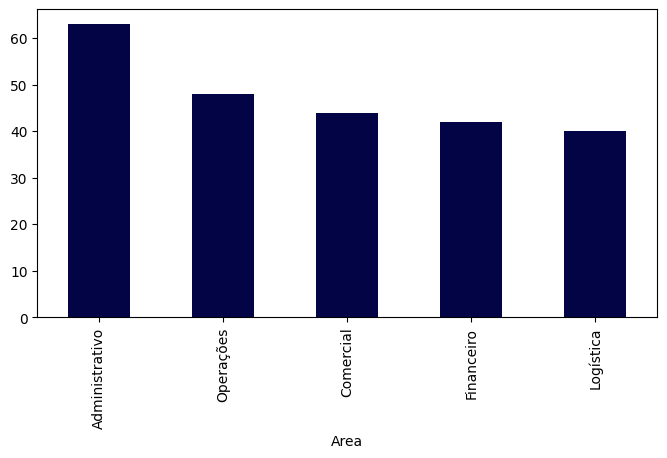

In [6]:
contratos_area_df = servicos_df[['ID Funcionário']].merge(funcionarios_df[['ID Funcionário', 'Area']])
qntd_contratos_area = contratos_area_df['Area'].value_counts()
print(qntd_contratos_area)
qntd_contratos_area.plot(kind='bar', color = '#020445', figsize=(8,4))

### 5 - Total de funcionários por área


Area
Administrativo    26
Comercial         26
Operações         23
Logística         21
Financeiro        18
Name: count, dtype: int64


<Axes: xlabel='Area'>

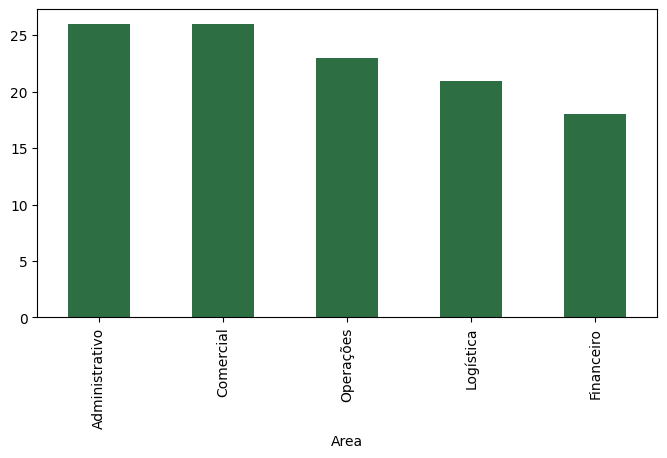

In [7]:
qntd_funcionarios_area = funcionarios_df['Area'].value_counts()
print(qntd_funcionarios_area)
qntd_funcionarios_area.plot(kind='bar', color = '#2d6e43', figsize = (8,4))


### 6 - Ticket médio mensal


In [8]:
ticket_medio = clientes_df['Valor Contrato Mensal'].mean()
print(f'Ticket médio mensal: R${ticket_medio:,.2f}')

Ticket médio mensal: R$2,502.56
